查看保存的模型参数

In [1]:
import torch

ckpt_path = r"F:\ANU_course\code_note\research_course\Alyssa_project\forget_int_pykt\examples\saved_model\forget_se_akt_qid_saved_model_3407_0_0.2_256_512_8_4_0.0001_32_1_1_7baea122-2765-4bd4-a216-c92343916d1b\qid_model.ckpt"
ckpt = torch.load(ckpt_path, map_location="cpu")

type(ckpt), ckpt.keys()

c:\Users\chill\.conda\envs\pykt\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(collections.OrderedDict,
 odict_keys(['difficult_param.weight', 'q_embed_diff.weight', 'qa_embed_diff.weight', 'q_embed.weight', 'qa_embed.weight', 'model.blocks_1.0.masked_attn_head.gammas', 'model.blocks_1.0.masked_attn_head.v_linear.weight', 'model.blocks_1.0.masked_attn_head.v_linear.bias', 'model.blocks_1.0.masked_attn_head.k_linear.weight', 'model.blocks_1.0.masked_attn_head.k_linear.bias', 'model.blocks_1.0.masked_attn_head.out_proj.weight', 'model.blocks_1.0.masked_attn_head.out_proj.bias', 'model.blocks_1.0.layer_norm1.weight', 'model.blocks_1.0.layer_norm1.bias', 'model.blocks_1.0.linear1.weight', 'model.blocks_1.0.linear1.bias', 'model.blocks_1.0.linear2.weight', 'model.blocks_1.0.linear2.bias', 'model.blocks_1.0.layer_norm2.weight', 'model.blocks_1.0.layer_norm2.bias', 'model.blocks_1.1.masked_attn_head.gammas', 'model.blocks_1.1.masked_attn_head.v_linear.weight', 'model.blocks_1.1.masked_attn_head.v_linear.bias', 'model.blocks_1.1.masked_attn_head.k_linear.weight', 'model

In [2]:
if isinstance(ckpt, dict) and "state_dict" in ckpt:       # Lightning
    sd = ckpt["state_dict"]
elif isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    sd = ckpt["model_state_dict"]
elif isinstance(ckpt, dict) and "model" in ckpt and isinstance(ckpt["model"], dict):
    sd = ckpt["model"]
elif isinstance(ckpt, dict):                               # 可能本身就是 state_dict
    sd = ckpt
else:
    raise ValueError("Unrecognized checkpoint format")

len(sd), list(sd.keys())[:20]

(191,
 ['difficult_param.weight',
  'q_embed_diff.weight',
  'qa_embed_diff.weight',
  'q_embed.weight',
  'qa_embed.weight',
  'model.blocks_1.0.masked_attn_head.gammas',
  'model.blocks_1.0.masked_attn_head.v_linear.weight',
  'model.blocks_1.0.masked_attn_head.v_linear.bias',
  'model.blocks_1.0.masked_attn_head.k_linear.weight',
  'model.blocks_1.0.masked_attn_head.k_linear.bias',
  'model.blocks_1.0.masked_attn_head.out_proj.weight',
  'model.blocks_1.0.masked_attn_head.out_proj.bias',
  'model.blocks_1.0.layer_norm1.weight',
  'model.blocks_1.0.layer_norm1.bias',
  'model.blocks_1.0.linear1.weight',
  'model.blocks_1.0.linear1.bias',
  'model.blocks_1.0.linear2.weight',
  'model.blocks_1.0.linear2.bias',
  'model.blocks_1.0.layer_norm2.weight',
  'model.blocks_1.0.layer_norm2.bias'])

In [3]:
# 常见关键词：embedding, emb, qid, item, question
keywords = ["emb", "embedding", "qid", "question", "item"]

embed_keys = [k for k in sd.keys() if any(w in k.lower() for w in keywords)]
embed_keys[:50]

['q_embed_diff.weight',
 'qa_embed_diff.weight',
 'q_embed.weight',
 'qa_embed.weight']

In [4]:
import json
from pathlib import Path

# 使用当前项目中的 yousician 映射文件（相对路径）
# notebook 位于 pykt-toolkit/trials_nanxuan/，data 在 pykt-toolkit/data/
keyid2idx_path = Path("..") / "data" / "yousician" / "keyid2idx.json"
with open(keyid2idx_path, "r", encoding="utf-8") as f:
    keyid2idx = json.load(f)

# id (int) -> KC 名称（json 里 concepts 的 key）
concept_id2name = {int(v): k for k, v in keyid2idx["concepts"].items()}
# 若 json 里 value 已是 int，上面即可；若是字符串 "0","1" 则 int(v) 没问题
n_kc = len(concept_id2name)

IndexError: index 10 is out of bounds for axis 0 with size 10

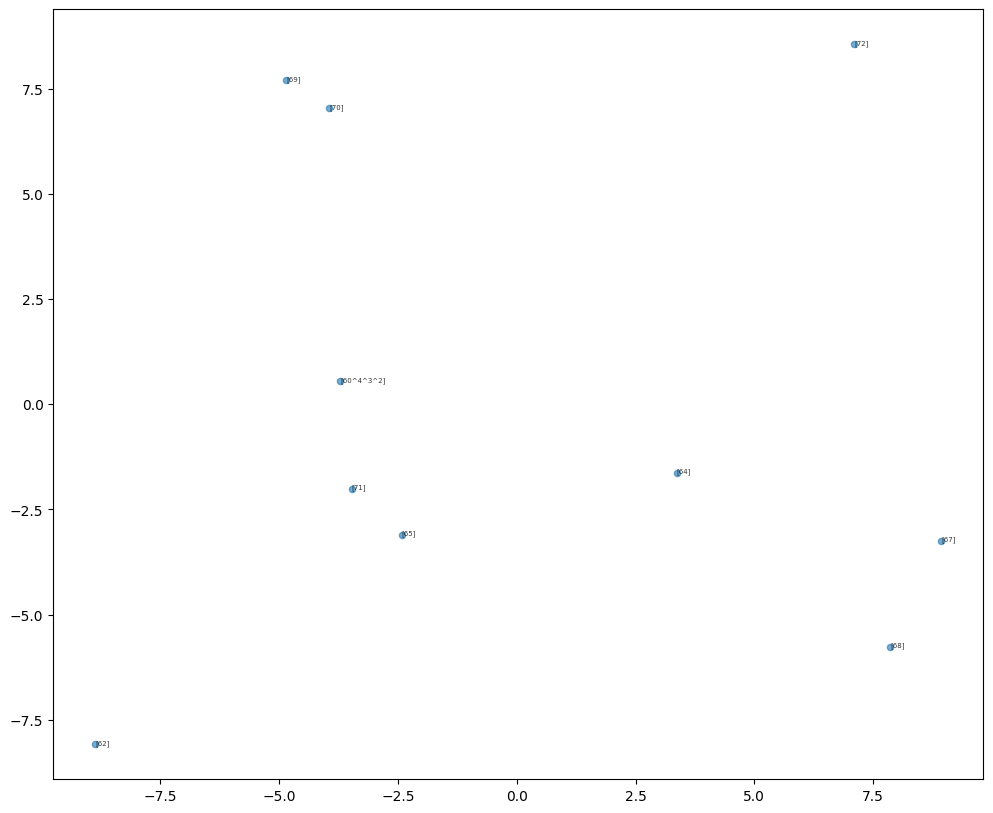

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 选择要可视化的 embedding 参数名（可按需要修改）
# 例如："q_embed.weight"、"qa_embed.weight"、"q_embed_diff.weight" 等
emb_key = "q_embed.weight"

# 从 state_dict 中取出权重并转为 numpy
W = sd[emb_key]
if hasattr(W, "detach"):
    W = W.detach().cpu().numpy()
else:
    W = np.array(W)

# 用 PCA 降到 2D
pca = PCA(n_components=2, random_state=0)
X2 = pca.fit_transform(W)

# 如果 embedding 数量大于 KC 数量，则只取前 n_kc 行与概念对齐
if X2.shape[0] > n_kc:
    X2 = X2[:n_kc]

fig, ax = plt.subplots(figsize=(12, 10))
ax.scatter(X2[:, 0], X2[:, 1], alpha=0.6, s=20, label="KC embeddings")

# 每个点标 KC 名称（从 json 查到的）
for i in range(n_kc):
    name = concept_id2name.get(i, str(i))
    ax.annotate(name, (X2[i, 0], X2[i, 1]), fontsize=5, alpha=0.8)

# 图例：只放前 10 个 id -> 名称，表示“对应关系”
legend_n = min(10, n_kc)
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='C0', markersize=8,
               label=f"{i}: {concept_id2name.get(i, '?')}")
    for i in range(legend_n)
]
legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='C0',
                                  markersize=8, label=f"... 共 {n_kc} 个 KC"))
ax.legend(handles=legend_handles, loc="best", fontsize=8)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("KC embeddings (PCA), 标注 = keyid2idx 中的名称")
plt.tight_layout()
plt.show()